In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv("/content/heart.csv")
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


##EDA(exploratory data analysis)

In [80]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [81]:
df.shape

(918, 12)

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [83]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [84]:
print('the num of dupllicates are ',df.duplicated().sum())

the num of dupllicates are  0


In [85]:
print('the num of nan',df.isnull().sum())

the num of nan Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


<Axes: xlabel='HeartDisease'>

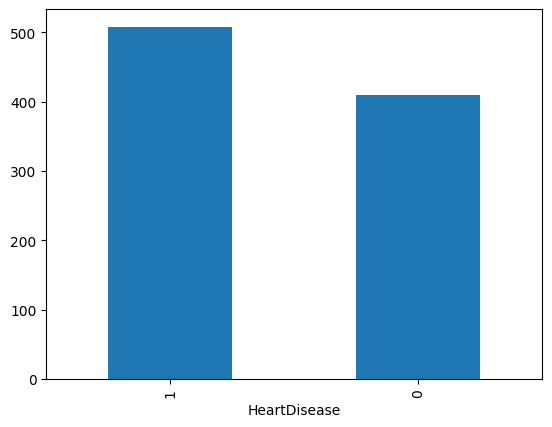

In [86]:
df['HeartDisease'].value_counts().plot(kind = 'bar')

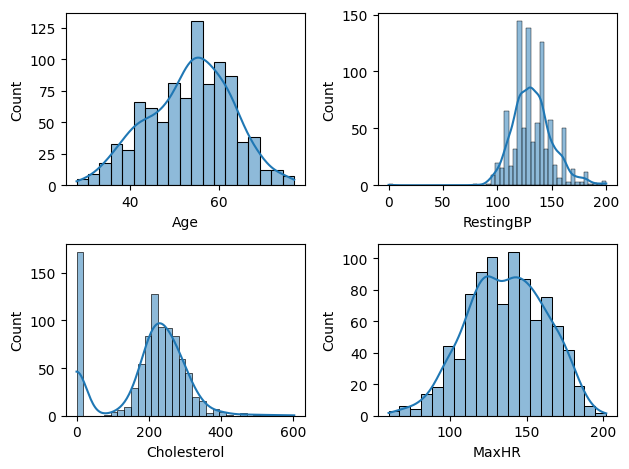

In [87]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting("Age",1)
plotting("RestingBP",2)
plotting("Cholesterol",3)
plotting("MaxHR",4)
plt.tight_layout()


In [88]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [89]:
ch_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()


In [90]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)
#“Replace all zero cholesterol values with the average cholesterol, then tidy it up by rounding to two decimal


In [91]:
resting_bp_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,ch_mean)
df['RestingBP'] = df['RestingBP'].round(2)

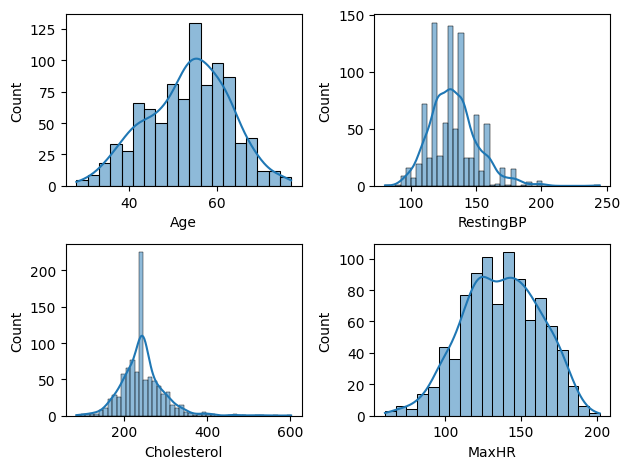

In [92]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde = True)

plotting("Age",1)
plotting("RestingBP",2)
plotting("Cholesterol",3)
plotting("MaxHR",4)
plt.tight_layout()


<Axes: xlabel='Sex', ylabel='count'>

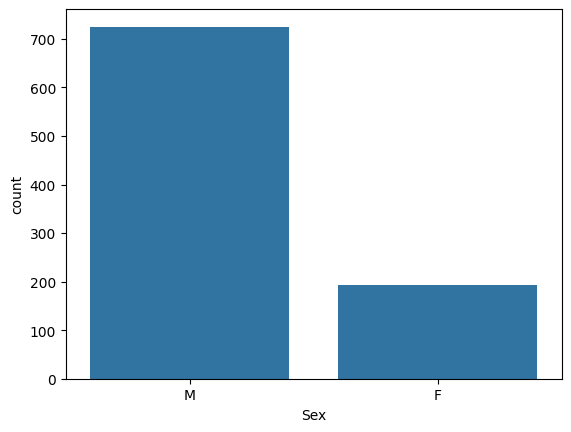

In [93]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='Sex', ylabel='count'>

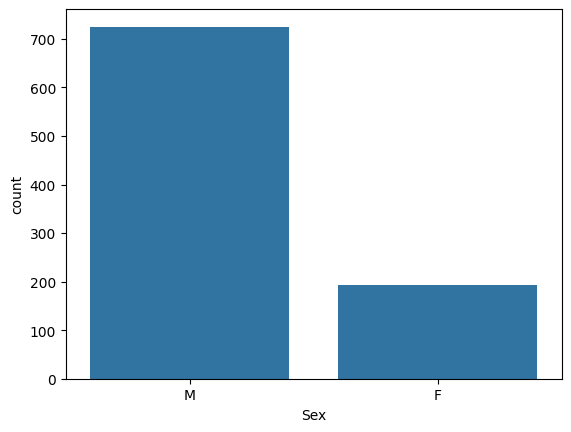

In [94]:
sns.countplot(x = df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

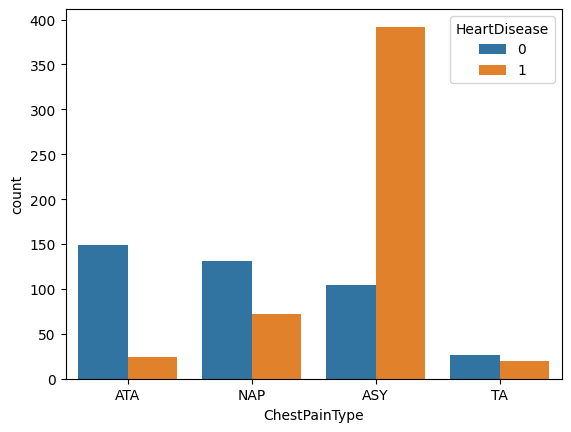

In [95]:
sns.countplot(x = df['ChestPainType'], hue  = df['HeartDisease'])

<Axes: xlabel='Sex', ylabel='count'>

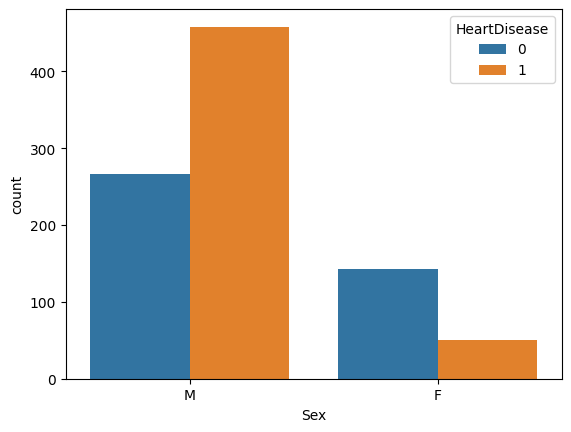

In [96]:
sns.countplot(x = df['Sex'], hue  = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

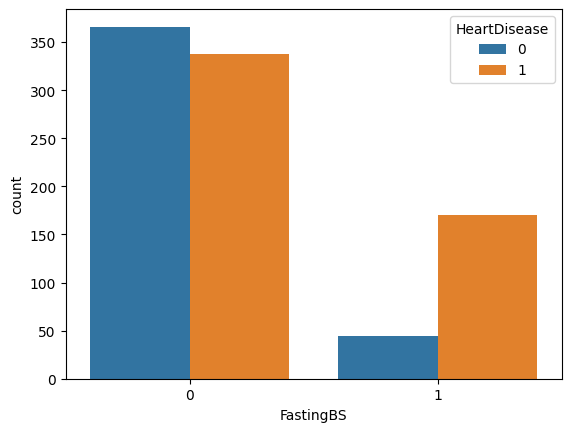

In [97]:
sns.countplot(x = df['FastingBS'], hue  = df['HeartDisease'])

<Axes: >

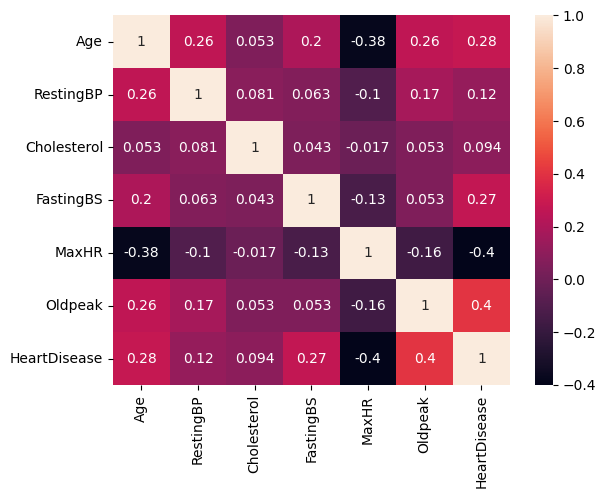

In [98]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

##Data Preprocessing and cleaning


In [99]:
df_encode = pd.get_dummies(df,drop_first = True)
df_encode = df_encode.astype(int)
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


In [100]:
from sklearn.preprocessing import StandardScaler
num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scal = StandardScaler()
df_encode[num_cols]=scal.fit_transform(df_encode[num_cols])

##Logistic Regression

In [101]:
#import libraries for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

X = df_encode.drop('HeartDisease', axis=1)  #Drop target column to get input features
y = df_encode['HeartDisease']  #Target variable: 0 = no heart disease, 1 = heart disease

In [102]:
#train-test split
#test_size=0.2 -> 20% of data for testing, 80% for training
#random_state=42 -> ensures reproducibility
#stratify=y -> keeps the same proportion of classes in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#initialize and train Logistic Regression
model = LogisticRegression()  # Create a Logistic Regression instance
model.fit(X_train, y_train)  # Train the model on training data


LogisticRegression()

In [103]:
#make prediction
y_pred = model.predict(X_test)  # Predict class labels (0 or 1)
y_prob = model.predict_proba(X_test)[:, 1]
# predict_proba() gives probability estimates for each class, [:,1] selects probability of class '1'

#evaluation
#accuracy: fraction of correct predictions
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8750


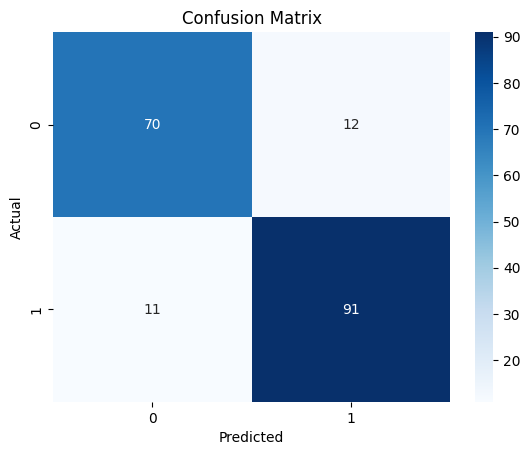

In [104]:
#Confusion Matrix: shows counts of TP, TN, FP, FN
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")  # Annot=True shows numbers in boxes
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


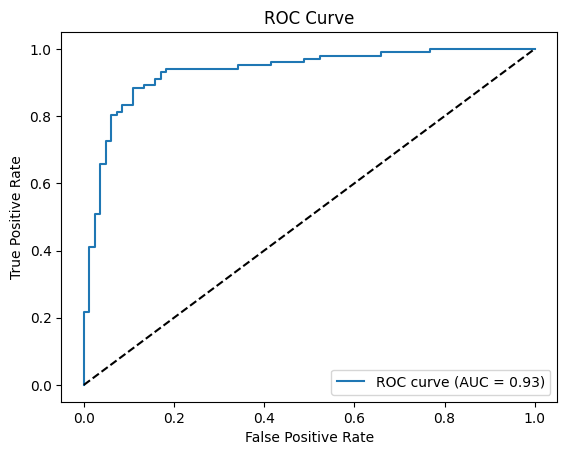

In [105]:
#ROC Curve: visualizes performance across all classification thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)  # fpr = false positive rate, tpr = true positive rate
roc_auc = roc_auc_score(y_test, y_prob)  # Area under ROC curve
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Dashed line representing random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [106]:
#Feature Importance: coefficients show how strongly each feature affects prediction
#Positive coefficients -> increase probability of heart disease
#Negative coefficients -> decrease probability
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False)  # Sort by absolute importance

print("Top features affecting prediction:")
print(feature_importance.head(10))  # Show top 10 features

Top features affecting prediction:
              Feature  Coefficient
8   ChestPainType_NAP    -1.571185
7   ChestPainType_ATA    -1.540015
14        ST_Slope_Up    -1.399897
6               Sex_M     1.298264
3           FastingBS     1.164838
9    ChestPainType_TA    -1.101224
13      ST_Slope_Flat     0.908153
12   ExerciseAngina_Y     0.844284
4               MaxHR    -0.293298
5             Oldpeak     0.254057


##Decision Tree

In [107]:
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Decision Tree model & plotting
#test_size=0.2 -> 20% test, 80% train
#random_state=42 -> reproducible results
#stratify=y -> maintain class balance in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#initialize and train Decision Tree
#max_depth can be adjusted to prevent overfitting
model = DecisionTreeClassifier(random_state=42, max_depth=4)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [108]:
#make predictions
y_pred = model.predict(X_test)  # Predicted class labels
y_prob = model.predict_proba(X_test)[:,1]  # Probability of class 1 (for ROC curve)

#evaluate model performance

#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.7989


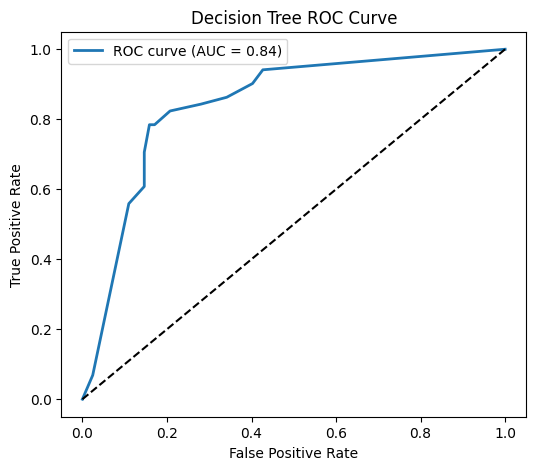

In [109]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend()
plt.show()


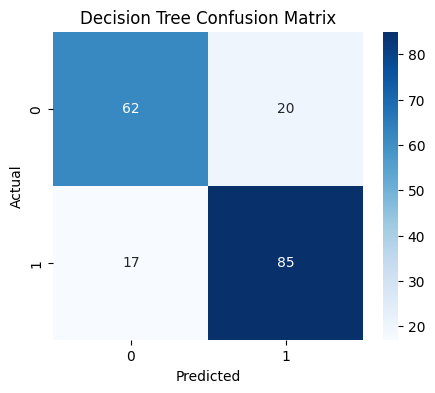

In [110]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()


/tmp/ipykernel_1136/544016950.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')


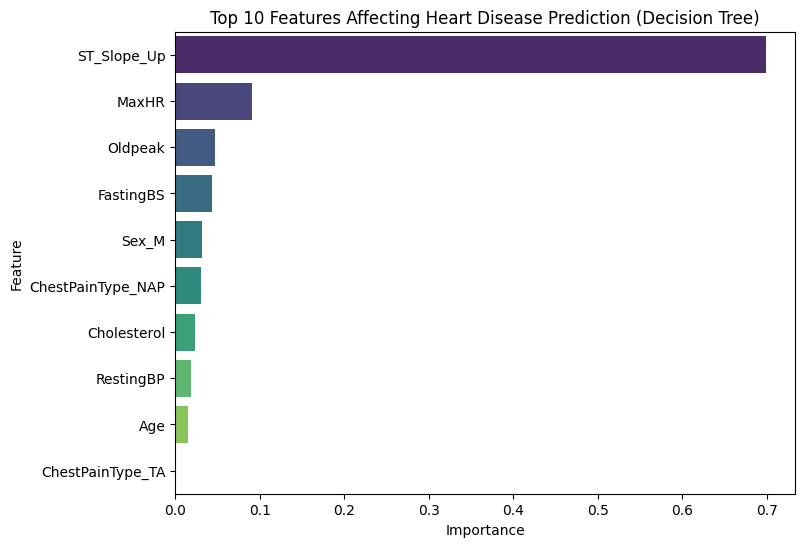

In [111]:
#feature Importance
#decision Trees have built-in feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10), palette='viridis')
plt.title('Top 10 Features Affecting Heart Disease Prediction (Decision Tree)')
plt.show()

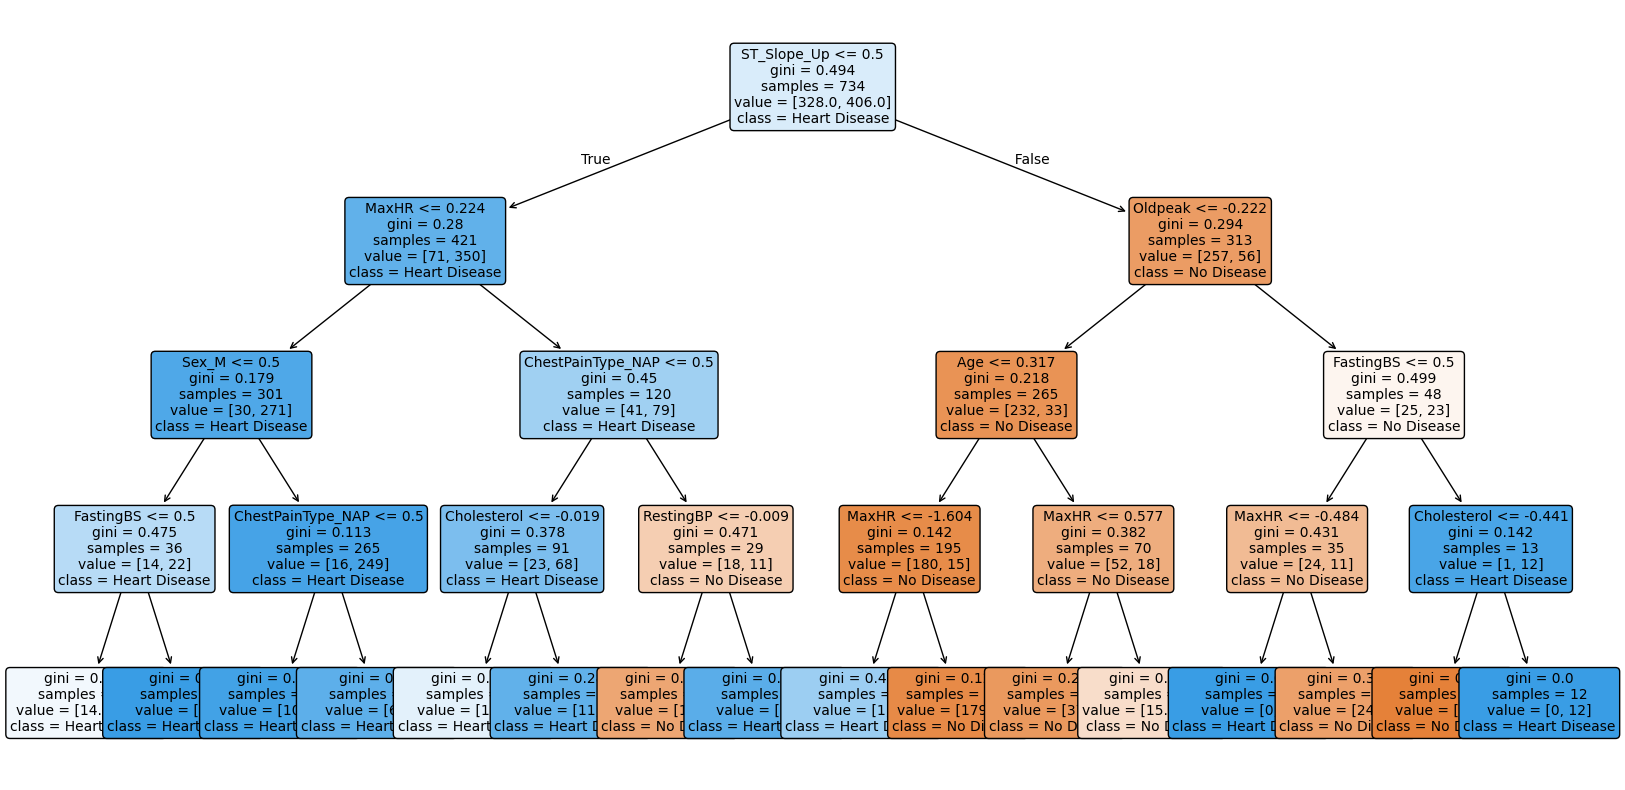

In [112]:
#Visualize the tree structure
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X.columns, class_names=['No Disease','Heart Disease'],
          filled=True, rounded=True, fontsize=10)
plt.show()

#Why Logistic Regression Performed Better than Decision Tree

Logistic Regression achieved higher accuracy (88%) compared to the Decision Tree (79%) primarily due to the nature of the dataset and how each model learns patterns.

Firstly, Logistic Regression works well when the relationship between features and the target variable is relatively linear. In this heart disease dataset, factors such as age, maximum heart rate, and exercise-induced angina tend to influence the outcome in a consistent and gradual way. Logistic Regression captures these smooth relationships effectively by assigning weights to each feature and combining them into a probability.

In contrast, the Decision Tree model makes predictions by splitting the data into rigid “if-else” rules. While this can capture complex patterns, it can also lead to overfitting—where the model learns noise from the training data instead of general patterns. As a result, the Decision Tree may perform well on training data but fail to generalize as effectively on unseen test data.

Additionally, feature scaling (using StandardScaler) improved the performance of Logistic Regression by ensuring all numerical features contributed equally to the model. Decision Trees, however, do not benefit from scaling, so they did not gain this advantage.

Finally, since the dataset is relatively small, simpler models like Logistic Regression tend to generalize better, whereas Decision Trees typically require more data to perform optimally.